# Source geometry sampling

This notebook is an automation pipeline to sample randomly various two-source geometries.

Constants: $v = 30$ km/h, $t_{acq} = 1$ s.

The procedure is as follows:

1. Sampling

There are samples taken for

- source activities ($A_1 = A_2$)
- positions $\vec{r}_1 = (x_1, y_1)$ and $\vec{r}_2 = (x_2, y_2)$, which are constrained based on the Maximum Detectable Distance (computed from $A$). See Finck et al. (2022) for definition of MDD.

2. Derived quantities

A few derived quantities are computed:

- source separation $d$
- distance to the road $r_1$
- distance to the road $r_2$

3. Generation using PG-RAD

For each sampled configuration, a YAML file compiled and data is simulated with PG-RAD. Output saved using the standard output from PG-RAD.

4. Bayesian pipeline

The generated data is passed into the Bayesian pipeline, and 10 simulations are done to determine the Localization Probability (LP).


## Imports

In [1]:
TRACE_OUT_FOLDER = "trace_output/"

In [2]:
from pathlib import Path
import json
import time

import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
import yaml
import arviz as az

from matplotlib import pyplot as plt
import matplotlib.patches as patches

from pg_rad.utils.projection import rel_to_abs_source_position as convert_pos

from run_model import run

In [3]:
with open('base_config.yml') as f:
    conf = yaml.safe_load(f)
conf

{'name': 'test',
 'speed': 8.33,
 'acquisition_time': 1,
 'path': {'length': [1000], 'segments': ['straight']},
 'sources': {'s1': {'activity_MBq': 100,
   'isotope': 'Cs137',
   'gamma_energy_keV': 662,
   'position': [0, 0, 0]},
  's2': {'activity_MBq': 100,
   'isotope': 'Cs137',
   'gamma_energy_keV': 662,
   'position': [0, 0, 0]}},
 'detector': 'LU_NaIR',
 'options': {'bkg_cps': 0}}

In [4]:
conf['speed'] = 8.33

## Maximum Detectable Distance (MDD) approximation
The approximation here is based on the 4L NaI(Tl) detector (right side) at 30km/h with optimal acquisition interval alignment.

In [5]:
def create_mdd_func(act, mdd):
    f = lambda x, a, b, c: a * x**b + c
    popt, _ = curve_fit(f, act, mdd)
    g = lambda x: f(x, *popt)
    return g

In [6]:
act_arr = [2.0E+07, 5.0E+07, 8.0E+07, 1.0E+08, 2.0E+08, 5.0E+08, 8.0E+08, 1.0E+09, 2.0E+09, 5.0E+09, 1.0E+10]
mdd_arr = [28.5,    44.4,    54.9,    60.4,    80.5,    113.2,   132.8,   142.7,   176.0,   225.3,   266.2]

mdd = create_mdd_func(act_arr, mdd_arr)

## Simulation parameters

In [7]:
SEED = 301
ACT_RANGE = [7, 10] # log_10
NUM_SIM = 10

## Initialize results DataFrame

In [8]:
df = pd.DataFrame(columns=["x1", "x2", "y1", "y2", "A1", "A2", "d", "theta", "r1", "r2", "A1/A2", "r1/r2", "LP"])
df.head()

,x1,x2,y1,y2,A1,A2,d,theta,r1,r2,A1/A2,r1/r2,LP


## Set random number generator

In [9]:
rng = np.random.default_rng(seed=SEED)

## Sampling activities

In [10]:
acts = 10 ** rng.uniform(*ACT_RANGE, (NUM_SIM, 2))
df["A1"] = acts[:, 0]
df["A2"] = acts[:, 1]
df.head()

,x1,x2,y1,y2,A1,A2,d,theta,r1,r2,A1/A2,r1/r2,LP
0,NaN,NaN,NaN,NaN,1.593023e+08,3.988941e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,1.103779e+08,6.034197e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,4.499418e+09,1.582752e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,1.974086e+07,1.330135e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,1.101738e+07,5.574848e+08,NaN,NaN,NaN,NaN,NaN,NaN,NaN


We use the **lowest** activity source to draw a MDD box, such that both sources can realistically be detected.

In [11]:
def calculate_sampling_box(acts):
    mdd_vals = mdd(acts)
    
    x_max = np.min(2 * mdd_vals, axis=1)
    x_min = np.zeros(mdd_vals.shape[:1])
    y_max = np.min(mdd_vals, axis=1)
    y_min = - y_max

    return x_min, x_max, y_min, y_max

In [12]:
x_min, x_max, y_min, y_max = calculate_sampling_box(acts)

In [13]:
x = rng.uniform(x_min[:, np.newaxis], x_max[:, np.newaxis], (NUM_SIM, 2))
y = rng.uniform(y_min[:, np.newaxis], y_max[:, np.newaxis], (NUM_SIM, 2))

df["x1"] = x[:, 0]
df["x2"] = x[:, 1]
df["y1"] = y[:, 0]
df["y2"] = y[:, 1]
df

,x1,x2,y1,y2,A1,A2,d,theta,r1,r2,A1/A2,r1/r2,LP
0,33.205641,10.285145,22.410669,-34.744642,1.593023e+08,3.988941e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,69.863382,88.571603,-29.880261,-20.095155,1.103779e+08,6.034197e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,249.313164,79.290191,94.481494,-76.685271,4.499418e+09,1.582752e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.631757,22.778743,-8.076392,-11.982472,1.974086e+07,1.330135e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,17.031690,20.912872,4.225373,9.298917,1.101738e+07,5.574848e+08,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,54.548919,102.238792,-2.825522,-49.016401,7.811638e+07,3.986856e+08,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,103.472261,78.398138,103.264857,59.250982,9.167851e+09,9.669439e+08,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,59.863422,10.056883,12.032334,9.884974,1.879019e+09,3.459746e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,61.700998,33.900560,78.656393,19.755372,7.372807e+09,2.010270e+08,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,62.074329,61.770881,17.788366,24.297013,3.955230e+07,3.211058e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN


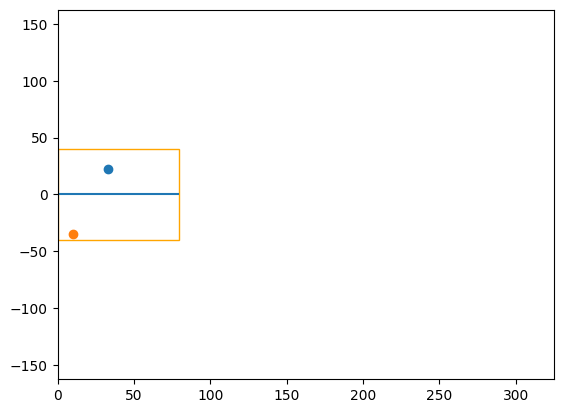

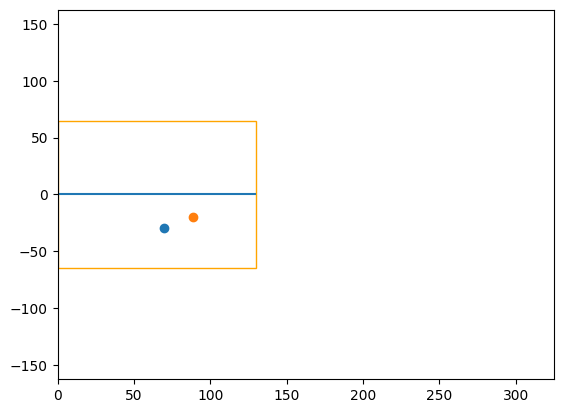

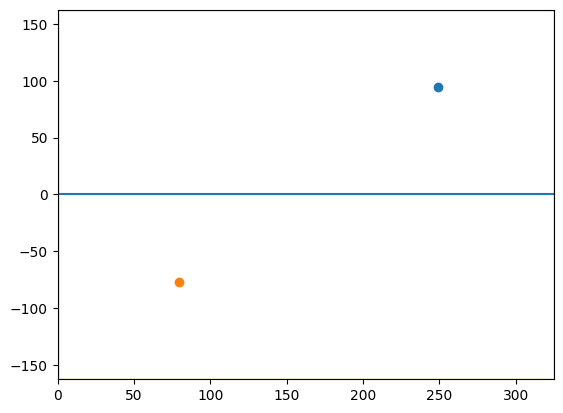

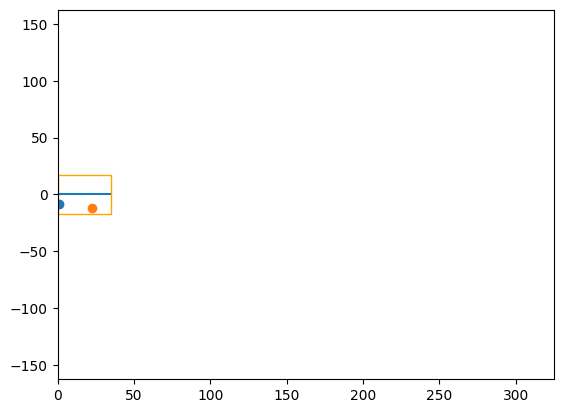

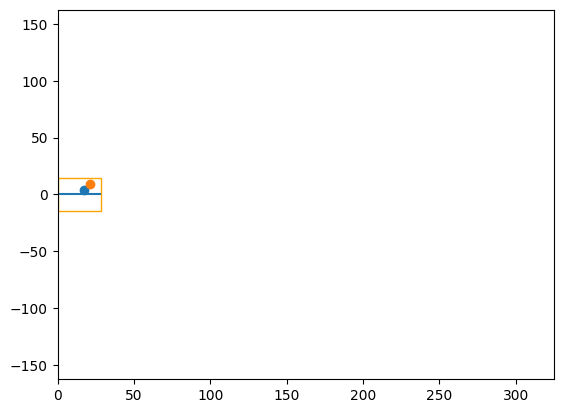

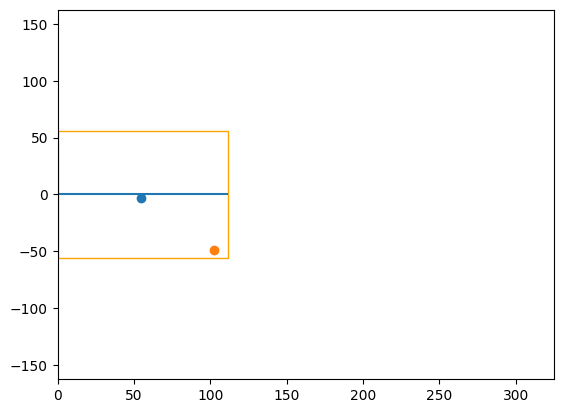

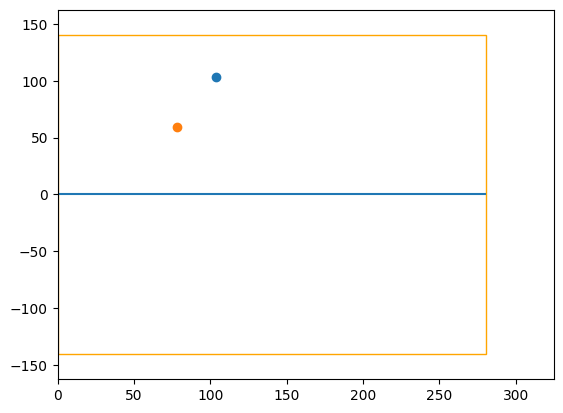

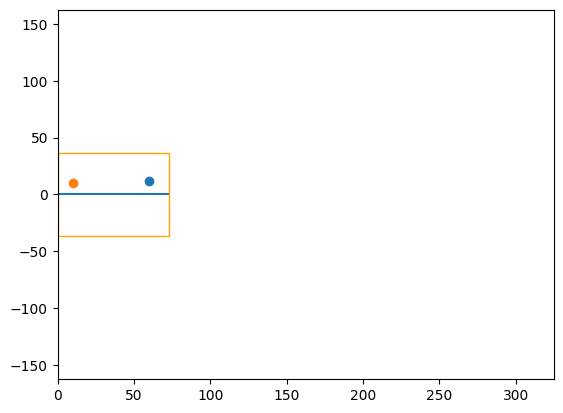

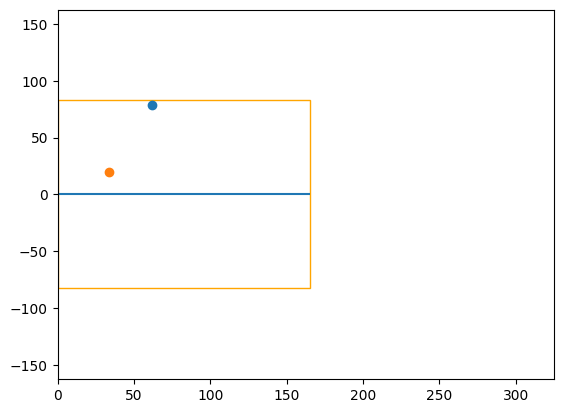

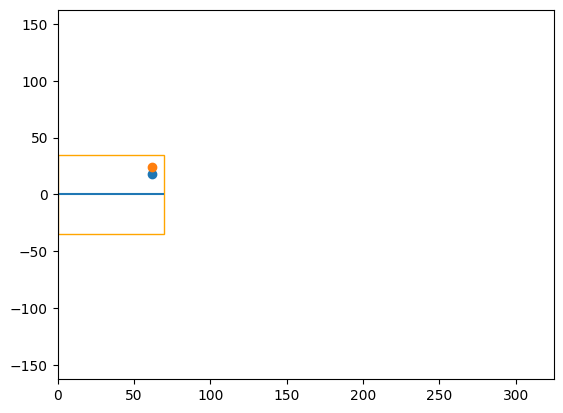

In [14]:
i = 0
for i in range(NUM_SIM):
    fig, ax = plt.subplots()
    width = x_max[i] - x_min[i]
    height = y_max[i] - y_min[i]
    
    square = patches.Rectangle((x_min[i], y_min[i]), width, height, edgecolor='orange', facecolor='none')
    ax.add_patch(square)
    ax.scatter(df["x1"][i], df["y1"][i])
    ax.scatter(df["x2"][i], df["y2"][i])
    ax.hlines(0, x_min[i], x_max[i])
    plt.xlim(x_min.min(), x_max.max())
    plt.ylim(y_min.min(), y_max.max())

## Derived quantities

#### Distance between sources

In [15]:
pairs = np.stack((x, y), axis=-1)
dist_vec = pairs[:, 0] - pairs[:, 1]

d = np.linalg.norm(dist_vec, axis=1)
theta = np.degrees(np.arctan2(np.abs(dist_vec[:, 1]), np.abs(dist_vec[:, 0])))

df["d"] = d
df["theta"] = theta
df.head()

,x1,x2,y1,y2,A1,A2,d,theta,r1,r2,A1/A2,r1/r2,LP
0,33.205641,10.285145,22.410669,-34.744642,1.593023e+08,3.988941e+07,61.579856,68.148165,NaN,NaN,NaN,NaN,NaN
1,69.863382,88.571603,-29.880261,-20.095155,1.103779e+08,6.034197e+09,21.112695,27.611266,NaN,NaN,NaN,NaN,NaN
2,249.313164,79.290191,94.481494,-76.685271,4.499418e+09,1.582752e+09,241.258933,45.192076,NaN,NaN,NaN,NaN,NaN
3,0.631757,22.778743,-8.076392,-11.982472,1.974086e+07,1.330135e+07,22.488807,10.002431,NaN,NaN,NaN,NaN,NaN
4,17.031690,20.912872,4.225373,9.298917,1.101738e+07,5.574848e+08,6.387834,52.584578,NaN,NaN,NaN,NaN,NaN


In [16]:
df["r1"] = np.abs(pairs[:, 0, 1])
df["r2"] = np.abs(pairs[:, 1, 1])
df["A1/A2"] = df[["A1","A2"]].max(axis=1) / df[["A1","A2"]].min(axis=1)
df["r1/r2"] = df[["r1","r2"]].max(axis=1) / df[["r1","r2"]].min(axis=1)
df

,x1,x2,y1,y2,A1,A2,d,theta,r1,r2,A1/A2,r1/r2,LP
0,33.205641,10.285145,22.410669,-34.744642,1.593023e+08,3.988941e+07,61.579856,68.148165,22.410669,34.744642,3.993598,1.550362,NaN
1,69.863382,88.571603,-29.880261,-20.095155,1.103779e+08,6.034197e+09,21.112695,27.611266,29.880261,20.095155,54.668533,1.486939,NaN
2,249.313164,79.290191,94.481494,-76.685271,4.499418e+09,1.582752e+09,241.258933,45.192076,94.481494,76.685271,2.842782,1.232068,NaN
3,0.631757,22.778743,-8.076392,-11.982472,1.974086e+07,1.330135e+07,22.488807,10.002431,8.076392,11.982472,1.484124,1.483642,NaN
4,17.031690,20.912872,4.225373,9.298917,1.101738e+07,5.574848e+08,6.387834,52.584578,4.225373,9.298917,50.600487,2.200733,NaN
5,54.548919,102.238792,-2.825522,-49.016401,7.811638e+07,3.986856e+08,66.392177,44.085236,2.825522,49.016401,5.103739,17.347733,NaN
6,103.472261,78.398138,103.264857,59.250982,9.167851e+09,9.669439e+08,50.655037,60.330407,103.264857,59.250982,9.481265,1.742838,NaN
7,59.863422,10.056883,12.032334,9.884974,1.879019e+09,3.459746e+07,49.852807,2.468723,12.032334,9.884974,54.310876,1.217235,NaN
8,61.700998,33.900560,78.656393,19.755372,7.372807e+09,2.010270e+08,65.132132,64.733361,78.656393,19.755372,36.675700,3.981519,NaN
9,62.074329,61.770881,17.788366,24.297013,3.955230e+07,3.211058e+07,6.515718,87.330670,17.788366,24.297013,1.231753,1.365894,NaN


In [17]:
def get_sim_path_and_csv_name(i, baseDir="output/"):
    folder_name = ! cd $baseDir && ls | grep $i*
    print("Detected folder name", folder_name)
    folder_name = folder_name[0]
    csv = ! cd $baseDir$folder_name && find *.csv
    print("Detected CSV name", csv)
    csv = csv[0]

    return baseDir+folder_name, csv

def get_sim_path_and_csv_name_2(i, base_dir="output"):
    base_path = Path(base_dir)
    # Find all directories matching the pattern f"{i}_result_*"
    folders = list(base_path.glob(f"{i}_result_*"))
    if not folders:
        raise FileNotFoundError(f"No folder matching {i}_result_* found in {base_dir}")

    folder_name = folders[0].name
    print("Detected folder name:", folder_name)

    # Find all CSV files in the folder
    csv_files = list(folders[0].glob("*.csv"))
    if not csv_files:
        raise FileNotFoundError(f"No CSV file found in {folders[0]}")

    csv_name = csv_files[0].name
    print("Detected CSV name:", csv_name)

    return str(folders[0]), csv_name

In [20]:
i = 1
for x_i, y_i, act_i, mdd_i in zip(x, y, acts, mdd(acts)):
    # Update conf
    conf['path']['length'] = [max(500, 3*int(mdd_i.max()))]
    conf['sources']['s1']['activity_MBq'] = float(act_i[0]/1E6)
    conf['sources']['s2']['activity_MBq'] = float(act_i[1]/1E6)
    conf['sources']['s1']['position'] = [float(conf['path']['length'][0]/2 + x_i[0]), float(y_i[0]), 0]
    conf['sources']['s2']['position'] = [float(conf['path']['length'][0]/2 + x_i[1]), float(y_i[1]), 0]
    conf['name'] = str(i)

    with open('tmp.yml', 'w') as f:
        yaml.dump(conf, f, default_flow_style=False)
    ! cd output && pgrad --config ../tmp.yml --save

    i += 1

2026-04-30 07:52:36,445 - INFO: Landscape built successfully: 1
<class 'numpy.bool'>
2026-04-30 07:52:36,465 - INFO: Simulation output saved to 1_result_20260430_0752!
2026-04-30 07:52:38,097 - INFO: Landscape built successfully: 2
<class 'numpy.bool'>
2026-04-30 07:52:38,109 - INFO: Simulation output saved to 2_result_20260430_0752!
2026-04-30 07:52:39,756 - INFO: Landscape built successfully: 3
<class 'numpy.bool'>
2026-04-30 07:52:39,769 - INFO: Simulation output saved to 3_result_20260430_0752!
2026-04-30 07:52:41,394 - INFO: Landscape built successfully: 4
<class 'numpy.bool'>
2026-04-30 07:52:41,406 - INFO: Simulation output saved to 4_result_20260430_0752!
2026-04-30 07:52:42,998 - INFO: Landscape built successfully: 5
<class 'numpy.bool'>
2026-04-30 07:52:43,009 - INFO: Simulation output saved to 5_result_20260430_0752!
2026-04-30 07:52:44,669 - INFO: Landscape built successfully: 6
<class 'numpy.bool'>
2026-04-30 07:52:44,683 - INFO: Simulation output saved to 6_result_2026043

In [21]:

for i in range(1, len(x)):
    csv_path, roi_filename = get_sim_path_and_csv_name_2(i)

    BASE_DIR = Path("__file__").resolve().parent
    CSV_DIR = Path(BASE_DIR.joinpath(csv_path))

    params_file = Path(CSV_DIR.joinpath("parameters.json"))
    params = json.load(params_file.open())

    csv_file = Path(CSV_DIR.joinpath(roi_filename))
    df = pd.read_csv(csv_file)

    trace, real_params = run(df, params, csv_file)
    az.to_netcdf(trace, filename=TRACE_OUT_FOLDER+str(i)+"_trace")
    df.to_pickle(TRACE_OUT_FOLDER+str(i)+"_pkl")

    with open(TRACE_OUT_FOLDER+str(i)+"_real_params",'w') as fp:
        json.dump(real_params, fp)

Detected folder name: 1_result_20260430_0752
Detected CSV name: 1_2_src_0_cps_bkg_159MBq_40MBq_22m_35m_283_22_260_-35.csv
[!] No 2 peaks found. Continuing...


/home/pim/miniforge3/envs/pg-rad-analysis/lib/python3.12/site-packages/pymc/sampling/mcmc.py:786: UserWarning: A list or tuple of random_seed no longer specifies the specific random_seed of each chain. Use a single seed instead.
  warnings.warn(
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [y_src, x_src, act_src]


Output()

Sampling 2 chains for 500 tune and 2_000 draw iterations (1_000 + 4_000 draws total) took 5 seconds.
There were 8 divergences after tuning. Increase `target_accept` or reparameterize.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [predicted_cps]


Output()

...

Detected folder name: 9_result_20260430_0752
Detected CSV name: 1_2_src_0_cps_bkg_7373MBq_201MBq_79m_20m_432_79_404_20.csv
[!] No 2 peaks found. Continuing...


/home/pim/miniforge3/envs/pg-rad-analysis/lib/python3.12/site-packages/pymc/sampling/mcmc.py:786: UserWarning: A list or tuple of random_seed no longer specifies the specific random_seed of each chain. Use a single seed instead.
  warnings.warn(
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [y_src, x_src, act_src]


Output()

Sampling 2 chains for 500 tune and 2_000 draw iterations (1_000 + 4_000 draws total) took 7 seconds.
There were 58 divergences after tuning. Increase `target_accept` or reparameterize.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [predicted_cps]


Output()